TypeError: Invalid shape (2, 128, 128) for image data

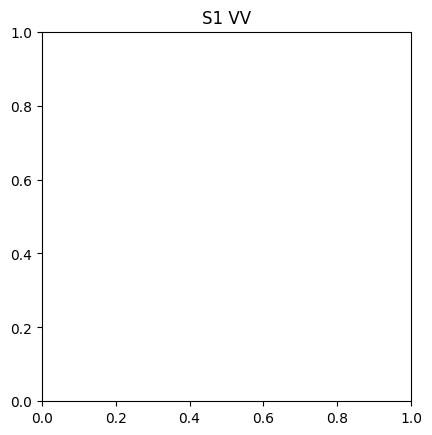

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#p = "/home/jakob/Bachelorprojekt/Kode/pipeline3/data/tiles_npz/S2A_MSIL2A_20250818T103041_N0511_R108_T33VUC_20250818T143613_r6400_c9728.npz"
#p = "/home/jakob/Bachelorprojekt/Kode/pipeline3/data/tiles_npz/S2A_MSIL2A_20250818T103041_N0511_R108_T33UUB_20250818T143613_r9984_c2560.npz"
#p = "/home/jakob/Bachelorprojekt/Kode/pipeline3/data/tiles_npz/S2A_MSIL2A_20250818T103041_N0511_R108_T32UNG_20250818T143613_r4352_c8960.npz"
#p = "/home/jakob/Bachelorprojekt/Kode/pipeline3/data/tiles_npz/S2A_MSIL2A_20250818T103041_N0511_R108_T32UNG_20250818T143613_r0_c2304.npz"
#p = "/home/jakob/Bachelorprojekt/Kode/pipeline3/data/tiles_npz/S2A_MSIL2A_20250818T103041_N0511_R108_T32VNH_20250818T143613_r9216_c6400.npz"
#p = "/home/jakob/Bachelorprojekt/Kode/pipeline3/data/tiles_npz/S2B_MSIL2A_20250818T101559_N0511_R065_T32VPH_20250818T125628_r9216_c8704.npz"
p = "/home/jakob/Bachelorprojekt/Kode/pipeline4-stitch-copernicus/data/tiles_npz/smoke_test__S2B_MSIL2A_20250612T102559_N0511_R108_20250612T124505__S1A_IW_GRDH_1SDV_20250612T170152_20250612T170217_059616_0766D2_670D.SAFE.npz"
d = np.load(p, allow_pickle=True)

vv = d["s1"][0]
rgb = np.stack([d["s2"][2], d["s2"][1], d["s2"][0]], axis=-1)  # R,G,B
mask = d["valid"].astype(bool)

plt.figure(); plt.title("S1 VV"); plt.imshow(vv, cmap="gray"); plt.colorbar()
plt.figure(); plt.title("S2 RGB"); plt.imshow(rgb / np.percentile(rgb, 98))
plt.figure(); plt.title("Valid mask"); plt.imshow(mask)
plt.show()

### Check if S1 and S2 align well in the NPZ files

Estimated shift to align S1->S2: dy=0 px, dx=0 px (peak=0.171)


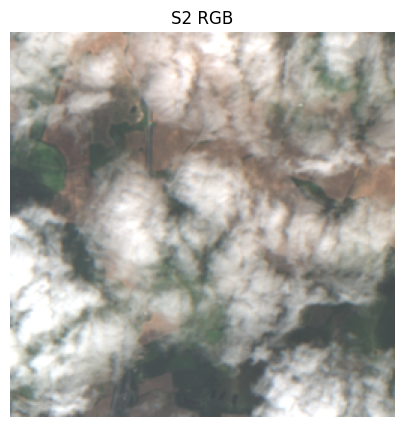

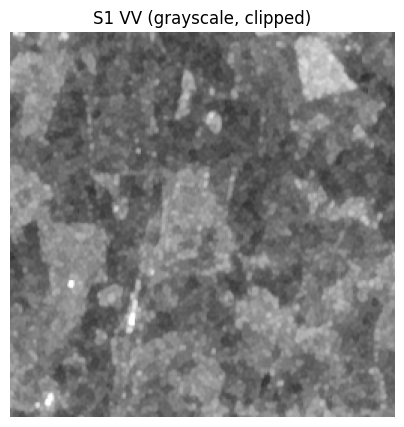

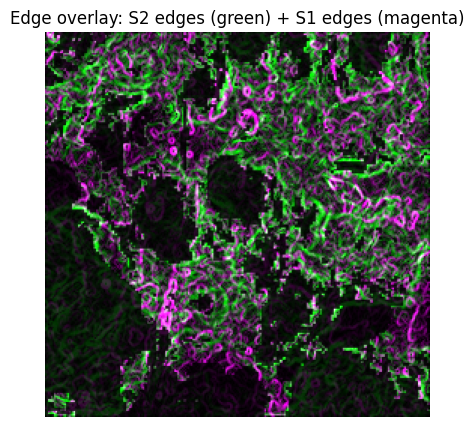

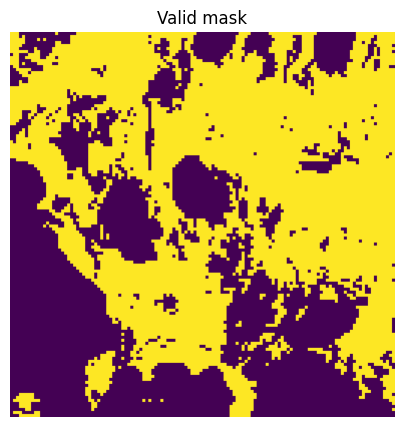

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def norm01(a, p=(2,98)):
    a = np.nan_to_num(a.astype(np.float32))
    lo, hi = np.percentile(a, p)
    return np.clip((a - lo) / (hi - lo + 1e-9), 0, 1)

def gradmag(img):
    # simple gradient magnitude (no extra libs)
    img = img.astype(np.float32)
    gx = np.zeros_like(img); gy = np.zeros_like(img)
    gx[:,1:-1] = (img[:,2:] - img[:,:-2]) * 0.5
    gy[1:-1,:] = (img[2:,:] - img[:-2,:]) * 0.5
    return np.hypot(gx, gy)

def phase_corr_shift(a, b, mask=None):
    """
    Estimate (dy, dx) shift aligning a -> b using phase correlation.
    a,b: 2D float arrays same shape.
    mask: boolean same shape; True where valid.
    """
    a = a.astype(np.float32); b = b.astype(np.float32)
    if mask is not None:
        a = np.where(mask, a, 0.0)
        b = np.where(mask, b, 0.0)

    # remove mean to reduce DC dominance
    a = a - a.mean()
    b = b - b.mean()

    Fa = np.fft.fft2(a)
    Fb = np.fft.fft2(b)
    R = Fa * np.conj(Fb)
    R /= (np.abs(R) + 1e-9)
    r = np.fft.ifft2(R).real

    # peak gives shift (wrap-around)
    peak = np.unravel_index(np.argmax(r), r.shape)
    py, px = peak
    H, W = r.shape
    dy = py if py < H//2 else py - H
    dx = px if px < W//2 else px - W
    return dy, dx, r[peak]

# ---- load one tile ----
p = "/home/jakob/Bachelorprojekt/Kode/pipeline2/data/tiles_npz/S2C_MSIL2A_20250819T104041_N0511_R008_T32UNG_20250819T155312_r8960_c2304.npz"
d = np.load(p, allow_pickle=True)

s1 = d["s1"].astype(np.float32)      # (2,H,W) in dB (VV,VH)
s2 = d["s2"].astype(np.float32)      # (4,H,W) (B02,B03,B04,B08)
mask = d["valid"].astype(bool)       # (H,W)

vv = s1[0]
vh = s1[1]

# S2 RGB (R,G,B = B04,B03,B02) and intensity
rgb = np.stack([s2[2], s2[1], s2[0]], axis=-1)
rgb_n = rgb / (np.percentile(rgb, 98) + 1e-9)
rgb_n = np.clip(rgb_n, 0, 1)

s2_int = (0.299*s2[2] + 0.587*s2[1] + 0.114*s2[0])  # simple intensity

# edges/gradients (more comparable across sensors than raw values)
g_s1 = gradmag(vv)
g_s2 = gradmag(s2_int)

g_s1n = norm01(g_s1)
g_s2n = norm01(g_s2)

# estimate pixel shift (dy, dx) using gradients and valid mask
dy, dx, peak = phase_corr_shift(g_s1n, g_s2n, mask=mask)
print(f"Estimated shift to align S1->S2: dy={dy} px, dx={dx} px (peak={peak:.3f})")

# ---- plots ----
plt.figure(figsize=(5,5)); plt.title("S2 RGB"); plt.imshow(rgb_n); plt.axis("off")

plt.figure(figsize=(5,5)); plt.title("S1 VV (grayscale, clipped)"); 
plt.imshow(vv, cmap="gray", vmin=-25, vmax=0); plt.axis("off")

plt.figure(figsize=(5,5)); plt.title("Edge overlay: S2 edges (green) + S1 edges (magenta)")
# overlay: green=S2, magenta=S1
overlay = np.zeros((g_s1n.shape[0], g_s1n.shape[1], 3), dtype=np.float32)
overlay[...,1] = g_s2n  # green
overlay[...,0] = g_s1n  # red
overlay[...,2] = g_s1n  # blue -> magenta
# dim invalid pixels
overlay[~mask] *= 0.2
plt.imshow(overlay); plt.axis("off")

plt.figure(figsize=(5,5)); plt.title("Valid mask"); plt.imshow(mask); plt.axis("off")

plt.show()
